Creating heatmap from minimarket.geojson...


Cannot find header.dxf (GDAL_DATA is not defined)


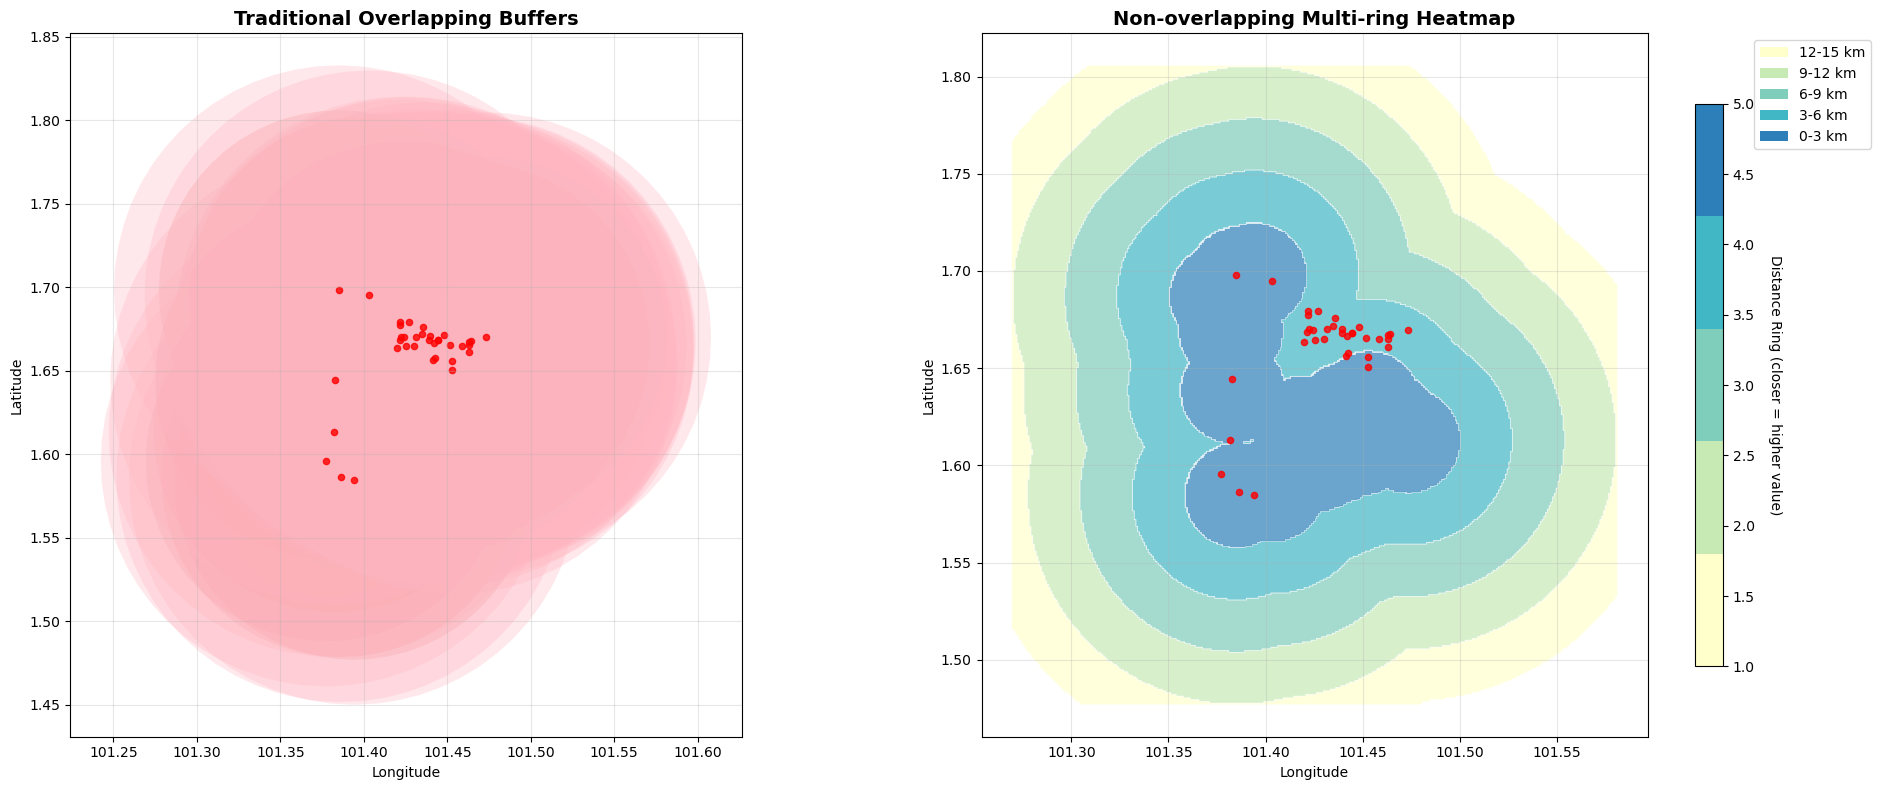

Successfully created heatmap with 7 polygon features

Heatmap data preview:
                                            geometry  ring distance_km  \
0  POLYGON ((101.30809 1.80583, 101.30809 1.80494...     1       12-15   
1  POLYGON ((101.38016 1.80494, 101.38016 1.80404...     2        9-12   
2  POLYGON ((101.39006 1.77887, 101.39006 1.77797...     3         6-9   
3  POLYGON ((101.39187 1.61346, 101.39187 1.61256...     4         3-6   
4  POLYGON ((101.38826 1.61256, 101.38826 1.61166...     4         3-6   

   intensity  
0          1  
1          2  
2          3  
3          4  
4          4  

Output saved to: minimarket_heatmap.geojson


In [1]:
import geopandas as gpd
import numpy as np
from shapely.geometry import Point
from scipy.spatial.distance import cdist
import rasterio
from rasterio.transform import from_bounds
from rasterio.features import rasterize
import json
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

def create_minimarket_heatmap(geojson_file, output_file=None, ring_distance=3000, pixel_size=100):
    """
    Create a multi-ring buffer heatmap from minimarket point data.
    
    Parameters:
    - geojson_file: path to GeoJSON file or GeoJSON data as dict
    - output_file: output file path for the heatmap (optional)
    - ring_distance: distance for each ring in meters (default: 3000m = 3km)
    - pixel_size: pixel size in meters for the raster grid (default: 100m)
    
    Returns:
    - GeoDataFrame with heatmap polygons
    - numpy array with distance values
    """
    
    # Load the data
    if isinstance(geojson_file, str):
        gdf = gpd.read_file(geojson_file)
    else:
        gdf = gpd.GeoDataFrame.from_features(geojson_file['features'])
    
    # Ensure we have a projected CRS for accurate distance calculations
    if gdf.crs is None or gdf.crs.is_geographic:
        # Use a suitable projected CRS (UTM or local projection)
        # Here we'll use a general mercator projection
        gdf = gdf.to_crs('EPSG:3857')  # Web Mercator
    
    # Get the bounds of all points with some padding
    bounds = gdf.total_bounds
    padding = ring_distance * 4  # Add padding for the buffer zones
    
    minx, miny, maxx, maxy = bounds
    minx -= padding
    miny -= padding
    maxx += padding
    maxy += padding
    
    # Create a grid
    width = int((maxx - minx) / pixel_size)
    height = int((maxy - miny) / pixel_size)
    
    # Create coordinate arrays for the grid
    x = np.linspace(minx, maxx, width)
    y = np.linspace(miny, maxy, height)
    xx, yy = np.meshgrid(x, y)
    
    # Flatten the grid coordinates
    grid_points = np.column_stack([xx.flatten(), yy.flatten()])
    
    # Extract minimarket coordinates
    minimarket_coords = np.array([[point.x, point.y] for point in gdf.geometry])
    
    # Calculate distances from each grid point to all minimarkets
    distances = cdist(grid_points, minimarket_coords)
    
    # Find the minimum distance to any minimarket for each grid point
    min_distances = np.min(distances, axis=1)
    
    # Create rings based on distance
    # Ring 1: 0-3km, Ring 2: 3-6km, Ring 3: 6-9km, etc.
    max_rings = 5  # Adjust as needed
    distance_grid = min_distances.reshape(height, width)
    
    # Create ring classifications
    ring_values = np.zeros_like(distance_grid)
    for i in range(max_rings):
        mask = (distance_grid >= i * ring_distance) & (distance_grid < (i + 1) * ring_distance)
        ring_values[mask] = max_rings - i  # Inverse so closest areas have highest values
    
    # Set areas beyond max distance to 0
    ring_values[distance_grid >= max_rings * ring_distance] = 0
    
    # Create transform for the raster
    transform = from_bounds(minx, miny, maxx, maxy, width, height)
    
    # Convert raster to polygons
    from rasterio import features
    
    # Create a list to store polygon features
    polygon_features = []
    
    for ring_value in range(1, max_rings + 1):
        mask = (ring_values == ring_value).astype(np.uint8)
        
        # Convert raster to polygons
        shapes = features.shapes(mask, mask=mask > 0, transform=transform)
        
        for shape, value in shapes:
            if value == 1:  # Only include areas with the ring value
                polygon_features.append({
                    'geometry': shape,
                    'properties': {
                        'ring': ring_value,
                        'distance_km': f"{(max_rings - ring_value) * ring_distance / 1000:.0f}-{(max_rings - ring_value + 1) * ring_distance / 1000:.0f}",
                        'intensity': ring_value
                    }
                })
    
    # Create GeoDataFrame
    if polygon_features:
        heatmap_gdf = gpd.GeoDataFrame.from_features(polygon_features, crs=gdf.crs)
        
        # Convert back to geographic coordinates if needed
        if gdf.crs != 'EPSG:4326':
            heatmap_gdf = heatmap_gdf.to_crs('EPSG:4326')
            gdf = gdf.to_crs('EPSG:4326')
    else:
        heatmap_gdf = gpd.GeoDataFrame()
    
    # Save to file if specified
    if output_file and not heatmap_gdf.empty:
        heatmap_gdf.to_file(output_file, driver='GeoJSON')
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Plot 1: Original overlapping buffers for comparison
    ax1.set_title('Traditional Overlapping Buffers', fontsize=14, fontweight='bold')
    colors_overlapping = ['lightblue', 'lightgreen', 'lightyellow', 'lightcoral', 'lightpink']
    
    # Create traditional buffers
    gdf_proj = gdf.to_crs('EPSG:3857') if gdf.crs != 'EPSG:3857' else gdf
    for i, color in enumerate(colors_overlapping):
        buffer_dist = (i + 1) * ring_distance
        buffers = gdf_proj.buffer(buffer_dist).to_crs('EPSG:4326')
        buffers.plot(ax=ax1, color=color, alpha=0.3, edgecolor='none')
    
    gdf.plot(ax=ax1, color='red', markersize=20, alpha=0.8)
    ax1.set_xlabel('Longitude')
    ax1.set_ylabel('Latitude')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Non-overlapping heatmap
    ax2.set_title('Non-overlapping Multi-ring Heatmap', fontsize=14, fontweight='bold')
    
    if not heatmap_gdf.empty:
        # Create custom colormap
        colors_heatmap = ['#ffffcc', '#c7e9b4', '#7fcdbb', '#41b6c4', '#2c7fb8']
        cmap = ListedColormap(colors_heatmap)
        
        heatmap_gdf.plot(column='ring', ax=ax2, cmap=cmap, alpha=0.7, 
                        edgecolor='white', linewidth=0.5)
        
        # Add colorbar
        sm = plt.cm.ScalarMappable(cmap=cmap, 
                                  norm=plt.Normalize(vmin=1, vmax=max_rings))
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax2, shrink=0.8)
        cbar.set_label('Distance Ring (closer = higher value)', rotation=270, labelpad=20)
        
        # Add legend
        legend_labels = []
        for i in range(1, max_rings + 1):
            start_km = (max_rings - i) * ring_distance / 1000
            end_km = (max_rings - i + 1) * ring_distance / 1000
            legend_labels.append(f'{start_km:.0f}-{end_km:.0f} km')
        
        # Create custom legend
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=colors_heatmap[i-1], 
                               label=legend_labels[i-1]) 
                          for i in range(1, min(len(legend_labels) + 1, len(colors_heatmap) + 1))]
        ax2.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.15, 1))
    
    gdf.plot(ax=ax2, color='red', markersize=20, alpha=0.8, zorder=5)
    ax2.set_xlabel('Longitude')
    ax2.set_ylabel('Latitude')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return heatmap_gdf, ring_values

def load_sample_data():
    """Create sample minimarket data for testing"""
    # Sample minimarket locations (longitude, latitude)
    sample_points = [
        [106.8456, -6.2088],  # Jakarta area
        [106.8556, -6.2188],
        [106.8356, -6.1988],
        [106.8656, -6.2288],
        [106.8256, -6.1888],
        [106.8756, -6.2388],
        [106.8156, -6.1788]
    ]
    
    features = []
    for i, (lon, lat) in enumerate(sample_points):
        features.append({
            'type': 'Feature',
            'properties': {
                'id': f'minimarket_{i+1}',
                'name': f'Minimarket {i+1}'
            },
            'geometry': {
                'type': 'Point',
                'coordinates': [lon, lat]
            }
        })
    
    return {
        'type': 'FeatureCollection',
        'features': features
    }

# Example usage
if __name__ == "__main__":
    # Load your minimarket data
    print("Creating heatmap from minimarket.geojson...")
    
    try:
        heatmap_gdf, distance_array = create_minimarket_heatmap(
            "C:/Users/ACER/Downloads/MINIMARKET DI KOTA DUMAI TAHUN 2025 IMPORTED AT 24_AUG_2025.geojson",
            output_file='minimarket_heatmap.geojson',
            ring_distance=3000,  # 3km per ring
            pixel_size=100       # 100m pixel resolution
        )
        
        print(f"Successfully created heatmap with {len(heatmap_gdf)} polygon features")
        print("\nHeatmap data preview:")
        if not heatmap_gdf.empty:
            print(heatmap_gdf.head())
            print(f"\nOutput saved to: minimarket_heatmap.geojson")
        else:
            print("No heatmap polygons were generated. Check your input data.")
            
    except FileNotFoundError:
        print("Error: Could not find 'minimarket.geojson' file.")
        print("Make sure the file exists in the same directory as this script.")
        
        # Fallback to sample data for demonstration
        print("\nUsing sample data instead...")
        sample_data = load_sample_data()
        heatmap_gdf, distance_array = create_minimarket_heatmap(
            sample_data, 
            output_file='sample_minimarket_heatmap.geojson',
            ring_distance=3000,
            pixel_size=100
        )
        
    except Exception as e:
        print(f"Error processing the data: {str(e)}")
        print("Please check your GeoJSON file format and try again.")

Creating heatmap from minimarket.geojson with administrative boundaries...
Loaded administrative boundaries: 1 features
Using administrative boundary extent for analysis area
Clipping heatmap to administrative boundaries...
Clipped heatmap: 3 features remaining after clipping


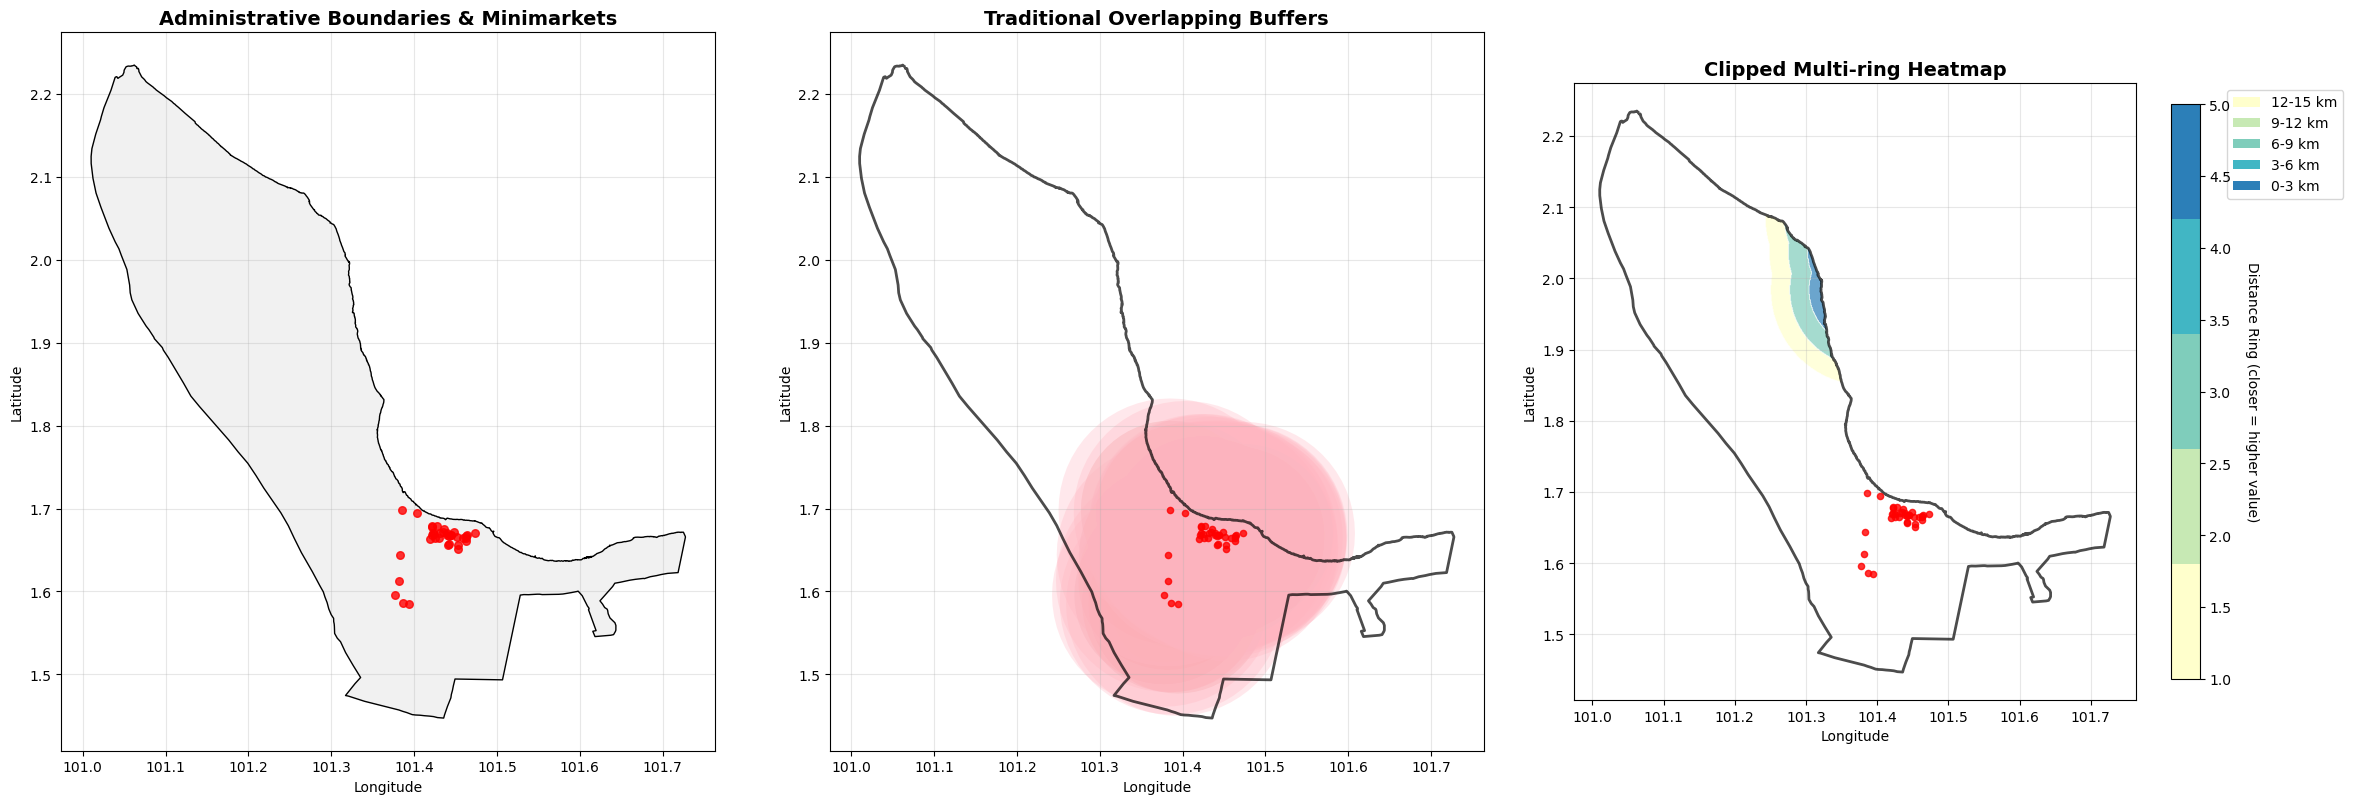

Successfully created heatmap with 3 polygon features
Administrative boundaries: 1 features loaded

Heatmap data preview:
                                            geometry  ring distance_km  \
2  POLYGON Z ((101.32834 1.92600 0.00000, 101.328...     3         6-9   
0  POLYGON Z ((101.34811 1.85414 0.00000, 101.348...     1       12-15   
1  POLYGON Z ((101.33822 1.88648 0.00000, 101.338...     2        9-12   

   intensity  
2          3  
0          1  
1          2  

Output saved to: minimarket_heatmap_clipped.geojson


In [2]:
import geopandas as gpd
import numpy as np
from shapely.geometry import Point
from scipy.spatial.distance import cdist
import rasterio
from rasterio.transform import from_bounds
from rasterio.features import rasterize
import json
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

def create_minimarket_heatmap(geojson_file, output_file=None, admin_boundary_file=None, ring_distance=3000, pixel_size=100):
    """
    Create a multi-ring buffer heatmap from minimarket point data, clipped to administrative boundaries.
    
    Parameters:
    - geojson_file: path to GeoJSON file or GeoJSON data as dict
    - output_file: output file path for the heatmap (optional)
    - admin_boundary_file: path to administrative boundary GeoJSON file (optional)
    - ring_distance: distance for each ring in meters (default: 3000m = 3km)
    - pixel_size: pixel size in meters for the raster grid (default: 100m)
    
    Returns:
    - GeoDataFrame with heatmap polygons (clipped to admin boundaries if provided)
    - numpy array with distance values
    """
    
    # Load the data
    if isinstance(geojson_file, str):
        gdf = gpd.read_file(geojson_file)
    else:
        gdf = gpd.GeoDataFrame.from_features(geojson_file['features'])
    
    # Load administrative boundaries if provided
    admin_gdf = None
    if admin_boundary_file:
        admin_gdf = gpd.read_file(admin_boundary_file)
        print(f"Loaded administrative boundaries: {len(admin_gdf)} features")
    
    # Ensure we have a projected CRS for accurate distance calculations
    if gdf.crs is None or gdf.crs.is_geographic:
        # Use a suitable projected CRS (UTM or local projection)
        # Here we'll use a general mercator projection
        gdf = gdf.to_crs('EPSG:3857')  # Web Mercator
    
    # Project admin boundaries to the same CRS
    if admin_gdf is not None:
        if admin_gdf.crs is None or admin_gdf.crs.is_geographic:
            admin_gdf = admin_gdf.to_crs('EPSG:3857')
        else:
            admin_gdf = admin_gdf.to_crs(gdf.crs)
    
    # Determine bounds - use admin boundaries if available, otherwise use points with padding
    if admin_gdf is not None:
        bounds = admin_gdf.total_bounds
        # Add small padding for admin boundaries
        padding = pixel_size * 10
        print("Using administrative boundary extent for analysis area")
    else:
        bounds = gdf.total_bounds
        padding = ring_distance * 4  # Add padding for the buffer zones
        print("Using point data extent with buffer padding for analysis area")
    
    minx, miny, maxx, maxy = bounds
    minx -= padding
    miny -= padding
    maxx += padding
    maxy += padding
    
    # Create a grid
    width = int((maxx - minx) / pixel_size)
    height = int((maxy - miny) / pixel_size)
    
    # Create coordinate arrays for the grid
    x = np.linspace(minx, maxx, width)
    y = np.linspace(miny, maxy, height)
    xx, yy = np.meshgrid(x, y)
    
    # Flatten the grid coordinates
    grid_points = np.column_stack([xx.flatten(), yy.flatten()])
    
    # Extract minimarket coordinates
    minimarket_coords = np.array([[point.x, point.y] for point in gdf.geometry])
    
    # Calculate distances from each grid point to all minimarkets
    distances = cdist(grid_points, minimarket_coords)
    
    # Find the minimum distance to any minimarket for each grid point
    min_distances = np.min(distances, axis=1)
    
    # Create rings based on distance
    # Ring 1: 0-3km, Ring 2: 3-6km, Ring 3: 6-9km, etc.
    max_rings = 5  # Adjust as needed
    distance_grid = min_distances.reshape(height, width)
    
    # Create ring classifications
    ring_values = np.zeros_like(distance_grid)
    for i in range(max_rings):
        mask = (distance_grid >= i * ring_distance) & (distance_grid < (i + 1) * ring_distance)
        ring_values[mask] = max_rings - i  # Inverse so closest areas have highest values
    
    # Set areas beyond max distance to 0
    ring_values[distance_grid >= max_rings * ring_distance] = 0
    
    # Create transform for the raster
    transform = from_bounds(minx, miny, maxx, maxy, width, height)
    
    # Convert raster to polygons
    from rasterio import features
    
    # Create a list to store polygon features
    polygon_features = []
    
    for ring_value in range(1, max_rings + 1):
        mask = (ring_values == ring_value).astype(np.uint8)
        
        # Convert raster to polygons
        shapes = features.shapes(mask, mask=mask > 0, transform=transform)
        
        for shape, value in shapes:
            if value == 1:  # Only include areas with the ring value
                polygon_features.append({
                    'geometry': shape,
                    'properties': {
                        'ring': ring_value,
                        'distance_km': f"{(max_rings - ring_value) * ring_distance / 1000:.0f}-{(max_rings - ring_value + 1) * ring_distance / 1000:.0f}",
                        'intensity': ring_value
                    }
                })
    
    # Create GeoDataFrame
    if polygon_features:
        heatmap_gdf = gpd.GeoDataFrame.from_features(polygon_features, crs=gdf.crs)
        
        # Clip to administrative boundaries if provided
        if admin_gdf is not None:
            print("Clipping heatmap to administrative boundaries...")
            
            # Dissolve admin boundaries to create a single boundary
            admin_dissolved = admin_gdf.dissolve()
            
            # Clip the heatmap to admin boundaries
            try:
                heatmap_gdf = gpd.clip(heatmap_gdf, admin_dissolved)
                print(f"Clipped heatmap: {len(heatmap_gdf)} features remaining after clipping")
            except Exception as e:
                print(f"Warning: Could not clip to admin boundaries: {e}")
                print("Proceeding with unclipped heatmap...")
        
        # Convert back to geographic coordinates if needed
        if gdf.crs != 'EPSG:4326':
            heatmap_gdf = heatmap_gdf.to_crs('EPSG:4326')
            gdf = gdf.to_crs('EPSG:4326')
            if admin_gdf is not None:
                admin_gdf = admin_gdf.to_crs('EPSG:4326')
    else:
        heatmap_gdf = gpd.GeoDataFrame()
        if admin_gdf is not None and admin_gdf.crs != 'EPSG:4326':
            admin_gdf = admin_gdf.to_crs('EPSG:4326')
    
    # Save to file if specified
    if output_file and not heatmap_gdf.empty:
        heatmap_gdf.to_file(output_file, driver='GeoJSON')
    
    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(24, 8)) if admin_gdf is not None else plt.subplots(1, 2, figsize=(20, 8))
    
    if admin_gdf is not None:
        ax1, ax2, ax3 = axes
        
        # Plot 1: Administrative boundaries with minimarket points
        ax1.set_title('Administrative Boundaries & Minimarkets', fontsize=14, fontweight='bold')
        admin_gdf.boundary.plot(ax=ax1, color='black', linewidth=1)
        admin_gdf.plot(ax=ax1, color='lightgray', alpha=0.3)
        gdf.plot(ax=ax1, color='red', markersize=30, alpha=0.8, zorder=5)
        ax1.set_xlabel('Longitude')
        ax1.set_ylabel('Latitude')
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Traditional overlapping buffers
        ax2.set_title('Traditional Overlapping Buffers', fontsize=14, fontweight='bold')
        colors_overlapping = ['lightblue', 'lightgreen', 'lightyellow', 'lightcoral', 'lightpink']
        
        # Show admin boundaries
        admin_gdf.boundary.plot(ax=ax2, color='black', linewidth=2, alpha=0.7)
        
        # Create traditional buffers
        gdf_proj = gdf.to_crs('EPSG:3857') if gdf.crs != 'EPSG:3857' else gdf
        for i, color in enumerate(colors_overlapping):
            buffer_dist = (i + 1) * ring_distance
            buffers = gdf_proj.buffer(buffer_dist).to_crs('EPSG:4326')
            buffers.plot(ax=ax2, color=color, alpha=0.3, edgecolor='none')
        
        gdf.plot(ax=ax2, color='red', markersize=20, alpha=0.8, zorder=5)
        ax2.set_xlabel('Longitude')
        ax2.set_ylabel('Latitude')
        ax2.grid(True, alpha=0.3)
        
        # Plot 3: Non-overlapping heatmap clipped to admin boundaries
        ax3.set_title('Clipped Multi-ring Heatmap', fontsize=14, fontweight='bold')
        
        # Show admin boundaries
        admin_gdf.boundary.plot(ax=ax3, color='black', linewidth=2, alpha=0.7)
        
    else:
        ax1, ax2 = axes
        
        # Plot 1: Traditional overlapping buffers
        ax1.set_title('Traditional Overlapping Buffers', fontsize=14, fontweight='bold')
        colors_overlapping = ['lightblue', 'lightgreen', 'lightyellow', 'lightcoral', 'lightpink']
        
        # Create traditional buffers
        gdf_proj = gdf.to_crs('EPSG:3857') if gdf.crs != 'EPSG:3857' else gdf
        for i, color in enumerate(colors_overlapping):
            buffer_dist = (i + 1) * ring_distance
            buffers = gdf_proj.buffer(buffer_dist).to_crs('EPSG:4326')
            buffers.plot(ax=ax1, color=color, alpha=0.3, edgecolor='none')
        
        gdf.plot(ax=ax1, color='red', markersize=20, alpha=0.8)
        ax1.set_xlabel('Longitude')
        ax1.set_ylabel('Latitude')
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Non-overlapping heatmap
        ax2 = ax2
        ax2.set_title('Non-overlapping Multi-ring Heatmap', fontsize=14, fontweight='bold')
    
    # Plot the heatmap on the appropriate axis
    final_ax = ax3 if admin_gdf is not None else ax2
    
    if not heatmap_gdf.empty:
        # Create custom colormap
        colors_heatmap = ['#ffffcc', '#c7e9b4', '#7fcdbb', '#41b6c4', '#2c7fb8']
        cmap = ListedColormap(colors_heatmap)
        
        heatmap_gdf.plot(column='ring', ax=final_ax, cmap=cmap, alpha=0.7, 
                        edgecolor='white', linewidth=0.5)
        
        # Add colorbar
        sm = plt.cm.ScalarMappable(cmap=cmap, 
                                  norm=plt.Normalize(vmin=1, vmax=max_rings))
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=final_ax, shrink=0.8)
        cbar.set_label('Distance Ring (closer = higher value)', rotation=270, labelpad=20)
        
        # Add legend
        legend_labels = []
        for i in range(1, max_rings + 1):
            start_km = (max_rings - i) * ring_distance / 1000
            end_km = (max_rings - i + 1) * ring_distance / 1000
            legend_labels.append(f'{start_km:.0f}-{end_km:.0f} km')
        
        # Create custom legend
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=colors_heatmap[i-1], 
                               label=legend_labels[i-1]) 
                          for i in range(1, min(len(legend_labels) + 1, len(colors_heatmap) + 1))]
        final_ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.15, 1))
    
    gdf.plot(ax=final_ax, color='red', markersize=20, alpha=0.8, zorder=5)
    final_ax.set_xlabel('Longitude')
    final_ax.set_ylabel('Latitude')
    final_ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return heatmap_gdf, ring_values, admin_gdf

def load_sample_data():
    """Create sample minimarket data for testing"""
    # Sample minimarket locations (longitude, latitude)
    sample_points = [
        [106.8456, -6.2088],  # Jakarta area
        [106.8556, -6.2188],
        [106.8356, -6.1988],
        [106.8656, -6.2288],
        [106.8256, -6.1888],
        [106.8756, -6.2388],
        [106.8156, -6.1788]
    ]
    
    features = []
    for i, (lon, lat) in enumerate(sample_points):
        features.append({
            'type': 'Feature',
            'properties': {
                'id': f'minimarket_{i+1}',
                'name': f'Minimarket {i+1}'
            },
            'geometry': {
                'type': 'Point',
                'coordinates': [lon, lat]
            }
        })
    
    return {
        'type': 'FeatureCollection',
        'features': features
    }

# Example usage
if __name__ == "__main__":
    # Load your minimarket data with administrative boundaries
    print("Creating heatmap from minimarket.geojson with administrative boundaries...")
    
    try:
        heatmap_gdf, distance_array, admin_data = create_minimarket_heatmap(
            'C:/Users/ACER/Downloads/MINIMARKET DI KOTA DUMAI TAHUN 2025 IMPORTED AT 24_AUG_2025.geojson',
            output_file='minimarket_heatmap_clipped.geojson',
            admin_boundary_file='C:/Users/ACER/Downloads/BATAS ADMINISTRASI KOTA DUMAI TAHUN 2024 (SINGLE PART) IMPORTED AT 25_AUG_2025.geojson',  # Your administrative boundary file
            ring_distance=3000,  # 3km per ring
            pixel_size=100       # 100m pixel resolution
        )
        
        print(f"Successfully created heatmap with {len(heatmap_gdf)} polygon features")
        if admin_data is not None:
            print(f"Administrative boundaries: {len(admin_data)} features loaded")
        
        print("\nHeatmap data preview:")
        if not heatmap_gdf.empty:
            print(heatmap_gdf.head())
            print(f"\nOutput saved to: minimarket_heatmap_clipped.geojson")
        else:
            print("No heatmap polygons were generated. Check your input data.")
            
    except FileNotFoundError as e:
        missing_file = str(e).split("'")[1] if "'" in str(e) else "file"
        print(f"Error: Could not find '{missing_file}' file.")
        print("Make sure both 'minimarket.geojson' and 'batas.geojson' exist in the same directory.")
        
        # Try without admin boundaries
        try:
            print("\nTrying without administrative boundaries...")
            heatmap_gdf, distance_array, admin_data = create_minimarket_heatmap(
                'C:/Users/ACER/Downloads/MINIMARKET DI KOTA DUMAI TAHUN 2025 IMPORTED AT 24_AUG_2025.geojson',
                output_file='minimarket_heatmap_no_clip.geojson',
                admin_boundary_file=None,
                ring_distance=3000,
                pixel_size=100
            )
            print("Successfully created heatmap without administrative boundary clipping.")
        except FileNotFoundError:
            print("Could not find 'minimarket.geojson' either.")
            print("\nUsing sample data instead...")
            sample_data = load_sample_data()
            heatmap_gdf, distance_array, admin_data = create_minimarket_heatmap(
                sample_data, 
                output_file='sample_minimarket_heatmap.geojson',
                admin_boundary_file=None,
                ring_distance=3000,
                pixel_size=100
            )
            
    except Exception as e:
        print(f"Error processing the data: {str(e)}")
        print("Please check your GeoJSON file formats and try again.")

In [5]:
import geopandas as gpd
import numpy as np
from shapely.geometry import Point
from scipy.spatial.distance import cdist
import rasterio
from rasterio.transform import from_bounds
from rasterio.features import rasterize
import json
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

def create_minimarket_heatmap(geojson_file, output_file=None, admin_boundary_file=None, ring_distance=3000, pixel_size=100):
    """
    Create a multi-ring buffer heatmap from minimarket point data, clipped to administrative boundaries.
    
    Parameters:
    - geojson_file: path to GeoJSON file or GeoJSON data as dict
    - output_file: output file path for the heatmap (optional)
    - admin_boundary_file: path to administrative boundary GeoJSON file (optional)
    - ring_distance: distance for each ring in meters (default: 3000m = 3km)
    - pixel_size: pixel size in meters for the raster grid (default: 100m)
    
    Returns:
    - GeoDataFrame with heatmap polygons (clipped to admin boundaries if provided)
    - numpy array with distance values
    """
    
    # Load the data
    if isinstance(geojson_file, str):
        gdf = gpd.read_file(geojson_file)
    else:
        gdf = gpd.GeoDataFrame.from_features(geojson_file['features'])
    
    # Load administrative boundaries if provided
    admin_gdf = None
    if admin_boundary_file:
        admin_gdf = gpd.read_file(admin_boundary_file)
        print(f"Loaded administrative boundaries: {len(admin_gdf)} features")
    
    # Ensure we have a projected CRS for accurate distance calculations
    if gdf.crs is None or gdf.crs.is_geographic:
        # Use a suitable projected CRS (UTM or local projection)
        # Here we'll use a general mercator projection
        gdf = gdf.to_crs('EPSG:3857')  # Web Mercator
    
    # Project admin boundaries to the same CRS
    if admin_gdf is not None:
        if admin_gdf.crs is None or admin_gdf.crs.is_geographic:
            admin_gdf = admin_gdf.to_crs('EPSG:3857')
        else:
            admin_gdf = admin_gdf.to_crs(gdf.crs)
    
    # Determine bounds - use admin boundaries if available, otherwise use points with padding
    if admin_gdf is not None:
        bounds = admin_gdf.total_bounds
        # Add small padding for admin boundaries
        padding = pixel_size * 10
        print("Using administrative boundary extent for analysis area")
    else:
        bounds = gdf.total_bounds
        padding = ring_distance * 4  # Add padding for the buffer zones
        print("Using point data extent with buffer padding for analysis area")
    
    minx, miny, maxx, maxy = bounds
    minx -= padding
    miny -= padding
    maxx += padding
    maxy += padding
    
    # Create a grid
    width = int((maxx - minx) / pixel_size)
    height = int((maxy - miny) / pixel_size)
    
    # Create coordinate arrays for the grid
    x = np.linspace(minx, maxx, width)
    y = np.linspace(miny, maxy, height)
    xx, yy = np.meshgrid(x, y)
    
    # Flatten the grid coordinates
    grid_points = np.column_stack([xx.flatten(), yy.flatten()])
    
    # Extract minimarket coordinates
    minimarket_coords = np.array([[point.x, point.y] for point in gdf.geometry])
    
    # Calculate distances from each grid point to all minimarkets
    distances = cdist(grid_points, minimarket_coords)
    
    # Find the minimum distance to any minimarket for each grid point
    min_distances = np.min(distances, axis=1)
    
    # Create rings based on distance
    # Ring 1: 0-3km, Ring 2: 3-6km, Ring 3: 6-9km, etc., Ring 6: >15km
    max_rings = 5  # Buffer rings (0-15km)
    distance_grid = min_distances.reshape(height, width)
    
    # Create ring classifications
    ring_values = np.zeros_like(distance_grid)
    
    # Assign ring values for buffered areas (1-5 for 0-15km)
    for i in range(max_rings):
        mask = (distance_grid >= i * ring_distance) & (distance_grid < (i + 1) * ring_distance)
        ring_values[mask] = max_rings - i  # Inverse so closest areas have highest values
    
    # Create mask for admin boundary areas if provided
    if admin_gdf is not None:
        # Create a mask for areas within admin boundaries
        from rasterio.features import geometry_mask
        
        # Get admin boundary geometries
        admin_shapes = [geom for geom in admin_gdf.geometry]
        
        # Create mask for admin boundaries (False = inside boundary, True = outside)
        admin_mask = geometry_mask(admin_shapes, transform=transform, 
                                 invert=False, out_shape=(height, width))
        
        # Areas beyond max buffer distance but within admin boundaries = class 6 (>15km)
        beyond_buffer_mask = (distance_grid >= max_rings * ring_distance) & (~admin_mask)
        ring_values[beyond_buffer_mask] = 6  # Class for >15km areas
        
        # Set areas outside admin boundaries to 0 (no data)
        ring_values[admin_mask] = 0
    else:
        # Without admin boundaries, set areas beyond max distance to class 6
        beyond_buffer_mask = distance_grid >= max_rings * ring_distance
        ring_values[beyond_buffer_mask] = 6
    
    # Create transform for the raster
    transform = from_bounds(minx, miny, maxx, maxy, width, height)
    
    # Convert raster to polygons
    from rasterio import features
    
    # Create a list to store polygon features
    polygon_features = []
    
    for ring_value in range(1, max_rings + 1):
        mask = (ring_values == ring_value).astype(np.uint8)
        
        # Convert raster to polygons
        shapes = features.shapes(mask, mask=mask > 0, transform=transform)
        
        for shape, value in shapes:
            if value == 1:  # Only include areas with the ring value
                polygon_features.append({
                    'geometry': shape,
                    'properties': {
                        'ring': ring_value,
                        'distance_km': f"{(max_rings - ring_value) * ring_distance / 1000:.0f}-{(max_rings - ring_value + 1) * ring_distance / 1000:.0f}",
                        'intensity': ring_value
                    }
                })
    
    # Create GeoDataFrame
    if polygon_features:
        heatmap_gdf = gpd.GeoDataFrame.from_features(polygon_features, crs=gdf.crs)
        
        # Clip to administrative boundaries if provided
        if admin_gdf is not None:
            print("Clipping heatmap to administrative boundaries...")
            
            # Dissolve admin boundaries to create a single boundary
            admin_dissolved = admin_gdf.dissolve()
            
            # Clip the heatmap to admin boundaries
            try:
                heatmap_gdf = gpd.clip(heatmap_gdf, admin_dissolved)
                print(f"Clipped heatmap: {len(heatmap_gdf)} features remaining after clipping")
            except Exception as e:
                print(f"Warning: Could not clip to admin boundaries: {e}")
                print("Proceeding with unclipped heatmap...")
        
        # Convert back to geographic coordinates if needed
        if gdf.crs != 'EPSG:4326':
            heatmap_gdf = heatmap_gdf.to_crs('EPSG:4326')
            gdf = gdf.to_crs('EPSG:4326')
            if admin_gdf is not None:
                admin_gdf = admin_gdf.to_crs('EPSG:4326')
    else:
        heatmap_gdf = gpd.GeoDataFrame()
        if admin_gdf is not None and admin_gdf.crs != 'EPSG:4326':
            admin_gdf = admin_gdf.to_crs('EPSG:4326')
    
    # Save to file if specified
    if output_file and not heatmap_gdf.empty:
        heatmap_gdf.to_file(output_file, driver='GeoJSON')
    
    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(24, 8)) if admin_gdf is not None else plt.subplots(1, 2, figsize=(20, 8))
    
    if admin_gdf is not None:
        ax1, ax2, ax3 = axes
        
        # Plot 1: Administrative boundaries with minimarket points
        ax1.set_title('Administrative Boundaries & Minimarkets', fontsize=14, fontweight='bold')
        admin_gdf.boundary.plot(ax=ax1, color='black', linewidth=1)
        admin_gdf.plot(ax=ax1, color='lightgray', alpha=0.3)
        gdf.plot(ax=ax1, color='red', markersize=30, alpha=0.8, zorder=5)
        ax1.set_xlabel('Longitude')
        ax1.set_ylabel('Latitude')
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Traditional overlapping buffers
        ax2.set_title('Traditional Overlapping Buffers', fontsize=14, fontweight='bold')
        colors_overlapping = ['lightblue', 'lightgreen', 'lightyellow', 'lightcoral', 'lightpink']
        
        # Show admin boundaries
        admin_gdf.boundary.plot(ax=ax2, color='black', linewidth=2, alpha=0.7)
        
        # Create traditional buffers
        gdf_proj = gdf.to_crs('EPSG:3857') if gdf.crs != 'EPSG:3857' else gdf
        for i, color in enumerate(colors_overlapping):
            buffer_dist = (i + 1) * ring_distance
            buffers = gdf_proj.buffer(buffer_dist).to_crs('EPSG:4326')
            buffers.plot(ax=ax2, color=color, alpha=0.3, edgecolor='none')
        
        gdf.plot(ax=ax2, color='red', markersize=20, alpha=0.8, zorder=5)
        ax2.set_xlabel('Longitude')
        ax2.set_ylabel('Latitude')
        ax2.grid(True, alpha=0.3)
        
        # Plot 3: Non-overlapping heatmap clipped to admin boundaries
        ax3.set_title('Clipped Multi-ring Heatmap', fontsize=14, fontweight='bold')
        
        # Show admin boundaries
        admin_gdf.boundary.plot(ax=ax3, color='black', linewidth=2, alpha=0.7)
        
    else:
        ax1, ax2 = axes
        
        # Plot 1: Traditional overlapping buffers
        ax1.set_title('Traditional Overlapping Buffers', fontsize=14, fontweight='bold')
        colors_overlapping = ['lightblue', 'lightgreen', 'lightyellow', 'lightcoral', 'lightpink']
        
        # Create traditional buffers
        gdf_proj = gdf.to_crs('EPSG:3857') if gdf.crs != 'EPSG:3857' else gdf
        for i, color in enumerate(colors_overlapping):
            buffer_dist = (i + 1) * ring_distance
            buffers = gdf_proj.buffer(buffer_dist).to_crs('EPSG:4326')
            buffers.plot(ax=ax1, color=color, alpha=0.3, edgecolor='none')
        
        gdf.plot(ax=ax1, color='red', markersize=20, alpha=0.8)
        ax1.set_xlabel('Longitude')
        ax1.set_ylabel('Latitude')
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Non-overlapping heatmap
        ax2 = ax2
        ax2.set_title('Non-overlapping Multi-ring Heatmap', fontsize=14, fontweight='bold')
    
    # Plot the heatmap on the appropriate axis
    final_ax = ax3 if admin_gdf is not None else ax2
    
    if not heatmap_gdf.empty:
        # Create custom colormap
        colors_heatmap = ['#ffffcc', '#c7e9b4', '#7fcdbb', '#41b6c4', '#2c7fb8']
        cmap = ListedColormap(colors_heatmap)
        
        heatmap_gdf.plot(column='ring', ax=final_ax, cmap=cmap, alpha=0.7, 
                        edgecolor='white', linewidth=0.5)
        
        # Add colorbar
        sm = plt.cm.ScalarMappable(cmap=cmap, 
                                  norm=plt.Normalize(vmin=1, vmax=max_rings))
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=final_ax, shrink=0.8)
        cbar.set_label('Distance Ring (closer = higher value)', rotation=270, labelpad=20)
        
        # Add legend
        legend_labels = []
        for i in range(1, max_rings + 1):
            start_km = (max_rings - i) * ring_distance / 1000
            end_km = (max_rings - i + 1) * ring_distance / 1000
            legend_labels.append(f'{start_km:.0f}-{end_km:.0f} km')
        
        # Create custom legend
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=colors_heatmap[i-1], 
                               label=legend_labels[i-1]) 
                          for i in range(1, min(len(legend_labels) + 1, len(colors_heatmap) + 1))]
        final_ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.15, 1))
    
    gdf.plot(ax=final_ax, color='red', markersize=20, alpha=0.8, zorder=5)
    final_ax.set_xlabel('Longitude')
    final_ax.set_ylabel('Latitude')
    final_ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return heatmap_gdf, ring_values, admin_gdf

def load_sample_data():
    """Create sample minimarket data for testing"""
    # Sample minimarket locations (longitude, latitude)
    sample_points = [
        [106.8456, -6.2088],  # Jakarta area
        [106.8556, -6.2188],
        [106.8356, -6.1988],
        [106.8656, -6.2288],
        [106.8256, -6.1888],
        [106.8756, -6.2388],
        [106.8156, -6.1788]
    ]
    
    features = []
    for i, (lon, lat) in enumerate(sample_points):
        features.append({
            'type': 'Feature',
            'properties': {
                'id': f'minimarket_{i+1}',
                'name': f'Minimarket {i+1}'
            },
            'geometry': {
                'type': 'Point',
                'coordinates': [lon, lat]
            }
        })
    
    return {
        'type': 'FeatureCollection',
        'features': features
    }

# Example usage
if __name__ == "__main__":
    # Load your minimarket data with administrative boundaries
    print("Creating heatmap from minimarket.geojson with administrative boundaries...")
    
    try:
        heatmap_gdf, distance_array, admin_data = create_minimarket_heatmap(
            "C:/Users/ACER/Downloads/MINIMARKET DI KOTA DUMAI TAHUN 2025 IMPORTED AT 24_AUG_2025.geojson",
            output_file='minimarket_heatmap_clipped.geojson',
            admin_boundary_file="C:/Users/ACER/Downloads/BATAS ADMINISTRASI KOTA DUMAI TAHUN 2024 (SINGLE PART) IMPORTED AT 25_AUG_2025.geojson",  # Your administrative boundary file
            ring_distance=3000,  # 3km per ring
            pixel_size=100       # 100m pixel resolution
        )
        
        print(f"Successfully created heatmap with {len(heatmap_gdf)} polygon features")
        if admin_data is not None:
            print(f"Administrative boundaries: {len(admin_data)} features loaded")
        
        print("\nHeatmap data preview:")
        if not heatmap_gdf.empty:
            print(heatmap_gdf.head())
            print(f"\nOutput saved to: minimarket_heatmap_clipped.geojson")
        else:
            print("No heatmap polygons were generated. Check your input data.")
            
    except FileNotFoundError as e:
        missing_file = str(e).split("'")[1] if "'" in str(e) else "file"
        print(f"Error: Could not find '{missing_file}' file.")
        print("Make sure both 'minimarket.geojson' and 'batas.geojson' exist in the same directory.")
        
        # Try without admin boundaries
        try:
            print("\nTrying without administrative boundaries...")
            heatmap_gdf, distance_array, admin_data = create_minimarket_heatmap(
                "C:/Users/ACER/Downloads/MINIMARKET DI KOTA DUMAI TAHUN 2025 IMPORTED AT 24_AUG_2025.geojson",
                output_file='minimarket_heatmap_no_clip.geojson',
                admin_boundary_file=None,
                ring_distance=3000,
                pixel_size=100
            )
            print("Successfully created heatmap without administrative boundary clipping.")
        except FileNotFoundError:
            print("Could not find 'minimarket.geojson' either.")
            print("\nUsing sample data instead...")
            sample_data = load_sample_data()
            heatmap_gdf, distance_array, admin_data = create_minimarket_heatmap(
                sample_data, 
                output_file='sample_minimarket_heatmap.geojson',
                admin_boundary_file=None,
                ring_distance=3000,
                pixel_size=100
            )
            
    except Exception as e:
        print(f"Error processing the data: {str(e)}")
        print("Please check your GeoJSON file formats and try again.")

Creating heatmap from minimarket.geojson with administrative boundaries...
Loaded administrative boundaries: 1 features
Using administrative boundary extent for analysis area
Error processing the data: local variable 'transform' referenced before assignment
Please check your GeoJSON file formats and try again.
